# Galaxies and nebulae

This notebook calculates exposures for images of galaxies and nebulae. You give the target name, the instrument, the sky and the SNR that you need. *mphot* gives the sub-exposure time and the number of sub-exposures.

Section 5 needs an internet connection, to get survey images.

## 1. How it works

1. **Target.** *mphot* finds the target in the OpenNGC catalogue (size, magnitudes, type). For nebulae, it also uses Halpha fluxes and line ratios from other catalogues.
2. **Rates per pixel.** A galaxy covers many pixels. Thus *mphot* uses the surface brightness. The default is the mean in the catalogue ellipse. *mphot* calculates three rates per pixel [e⁻/s]: target $s$, sky $b$ and dark current $d$.
3. **Sub-exposure time.** *mphot* uses the shortest time that meets two conditions:
   - It is background-limited: $(b + d)\,t \geq 10\,\sigma_\mathrm{RN}^2$, where $\sigma_\mathrm{RN}$ is the read noise. The read noise then adds less than 5% to the noise.
   - The readout uses no more than 10% of the total time.

   If the brightest part of the target fills the well first, *mphot* uses a shorter time. If one exposure gives the SNR, *mphot* uses one exposure, because each readout adds read noise.
4. **Number of sub-exposures.** $n$ sub-exposures give

$$\mathrm{SNR} = \frac{\sqrt{n}\;s\,t}{\sqrt{(s + b + d)\,t + \sigma_\mathrm{RN}^2}} .$$

*mphot* uses the smallest $n$ that gives your SNR.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mphot

In [2]:
name, system_response = mphot.generate_system_response(
    "../resources/systems/speculoos_Andor_iKon-L-936_-60.csv",
    "../resources/filters/r.csv",
)

# sky properties
props_sky = {
    "pwv": 2.5,  # PWV [mm]
    "airmass": 1.2,  # airmass
    "seeing": 1.35,  # seeing (==FWHM) ["], used for the saturation of stars
}

# instrument properties
props_instrument = {
    "name": name,  # name of the system response
    "plate_scale": 0.35,  # pixel plate scale ["]
    "N_dc": 0.2,  # dark current [e/pix/s]
    "N_rn": 6.328,  # read noise [e_rms/pix]
    "well_depth": 64000,  # well depth [e/pix]
    "well_fill": 0.7,  # maximum fraction of the well to fill
    "read_time": 10.5,  # read time between images [s]
    "r0": 0.5,  # radius of telescope's primary mirror [m]
    "r1": 0.14,  # radius of telescope's secondary mirror [m]
}

In [3]:
target = mphot.resolve_target("M51")  # also "NGC 5194" or "Whirlpool Galaxy"
target

Target(name='NGC5194', label='M51 (NGC 5194, Whirlpool Galaxy)', kind='galaxy', object_type='G', ra=202.469625, dec=47.195166666666665, major_axis=13.71, minor_axis=11.67, position_angle=163.0, magnitudes={'B': 8.61, 'V': 8.36, 'J': 6.4, 'H': 5.65, 'K': 5.5}, radial_velocity=465.0, halpha_flux=None, halpha_source=None, line_ratios={}, c_hbeta=None)

## 2. Calculate the exposure

SNR 10 per pixel, at the mean surface brightness of M51:

In [4]:
plan = mphot.get_exposure_extended(target, props_instrument, props_sky, snr=10)

pd.Series({
    "Sub-exposure [s]": plan["t_sub [s]"],
    "Set by": plan["t_sub set by"],
    "Sub-exposures": plan["subs"],
    "Total exposure [min]": plan["exposure [s]"] / 60,
    "SNR per pixel in one sub-exposure": plan["SNR per sub"],
    "Stars over well_fill in one sub-exposure, brighter than [mag]": plan["saturation magnitude [mag]"],
    "Target centre reaches well_fill after [s]": plan["t_saturation [s]"],
    "Target [e/pix/s]": plan["N_target [e/pix/s]"],
    "Sky [e/pix/s]": plan["N_sky [e/pix/s]"],
}, dtype=object)

Sub-exposure [s]                                                        94.5
Set by                                                               readout
Sub-exposures                                                             10
Total exposure [min]                                                   15.75
SNR per pixel in one sub-exposure                                   3.302243
Stars over well_fill in one sub-exposure, brighter than [mag]      14.330727
Target centre reaches well_fill after [s]                        3093.896384
Target [e/pix/s]                                                    0.875005
Sky [e/pix/s]                                                       5.136155
dtype: object

In [5]:
for note in plan["warnings"]:
    print("-", note)

- The brightest part is the centre of an exponential disk. A bulge or nucleus is brighter and fills the well sooner. Use peak_offset to change this.


## 3. Time and SNR

The time increases as the square of the SNR. A fainter level needs more time. When the sky is the largest noise, 1 mag/arcsec² fainter needs approximately 6 times more time. `mu_offset` sets the level.

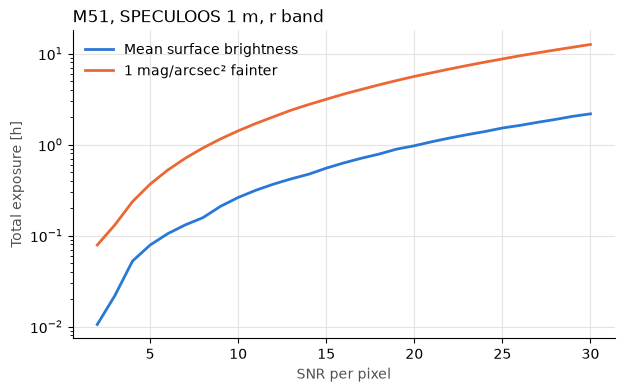

In [6]:
snrs = np.arange(2, 31)
levels = {0: "Mean surface brightness", 1: "1 mag/arcsec² fainter"}

INK_2, GRID = "#52514e", "#e4e3df"
COLORS = ["#2a78d6", "#eb6834"]

fig, ax = plt.subplots(figsize=(7, 4))
for (mu_offset, label), color in zip(levels.items(), COLORS):
    hours = [
        mphot.get_exposure_extended(
            target, props_instrument, props_sky, snr=snr, mu_offset=mu_offset
        )["exposure [s]"] / 3600
        for snr in snrs
    ]
    ax.plot(snrs, hours, color=color, lw=2, label=label)
ax.set_yscale("log")
ax.set_xlabel("SNR per pixel", color=INK_2)
ax.set_ylabel("Total exposure [h]", color=INK_2)
ax.set_title("M51, SPECULOOS 1 m, r band", loc="left")
ax.grid(color=GRID, lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False)
plt.show()

## 4. A nebula

For a nebula, *mphot* adds the emission lines in the filter band. The Ring Nebula (M57) with a 3 nm Halpha filter on a 0.5 m telescope:

In [7]:
halpha_name, _ = mphot.generate_system_response(
    "../resources/systems/generic_IMX461.csv", "../resources/filters/halpha.csv"
)
cmos = {
    "name": halpha_name, "plate_scale": 0.9, "N_dc": 0.1, "N_rn": 8.47,
    "well_depth": 1048560, "well_fill": 0.7, "read_time": 5, "r0": 0.254, "r1": 0.099,
}

p = mphot.get_exposure_extended("M57", cmos, props_sky, snr=20)
print(f"{p['subs']} x {p['t_sub [s]']:.0f} s for SNR 20 per pixel")
pd.Series(p["line counts [e/pix/s]"], name="e/pix/s")

1 x 46 s for SNR 20 per pixel


Halpha        8.610642
[NII] 6584    0.627613
[NII] 6548    0.937717
Name: e/pix/s, dtype: float64

## 5. M51 in each band

The catalogues give the brightness of a target, but not its shape. `synthetic_images.py` takes the shape from a survey image and adds the noise of the stack. Each image is one hour of sub-exposures with the plan from `get_exposure_extended`. The CCD gives u to z, the InGaAs camera gives zYJ to H. North is up.

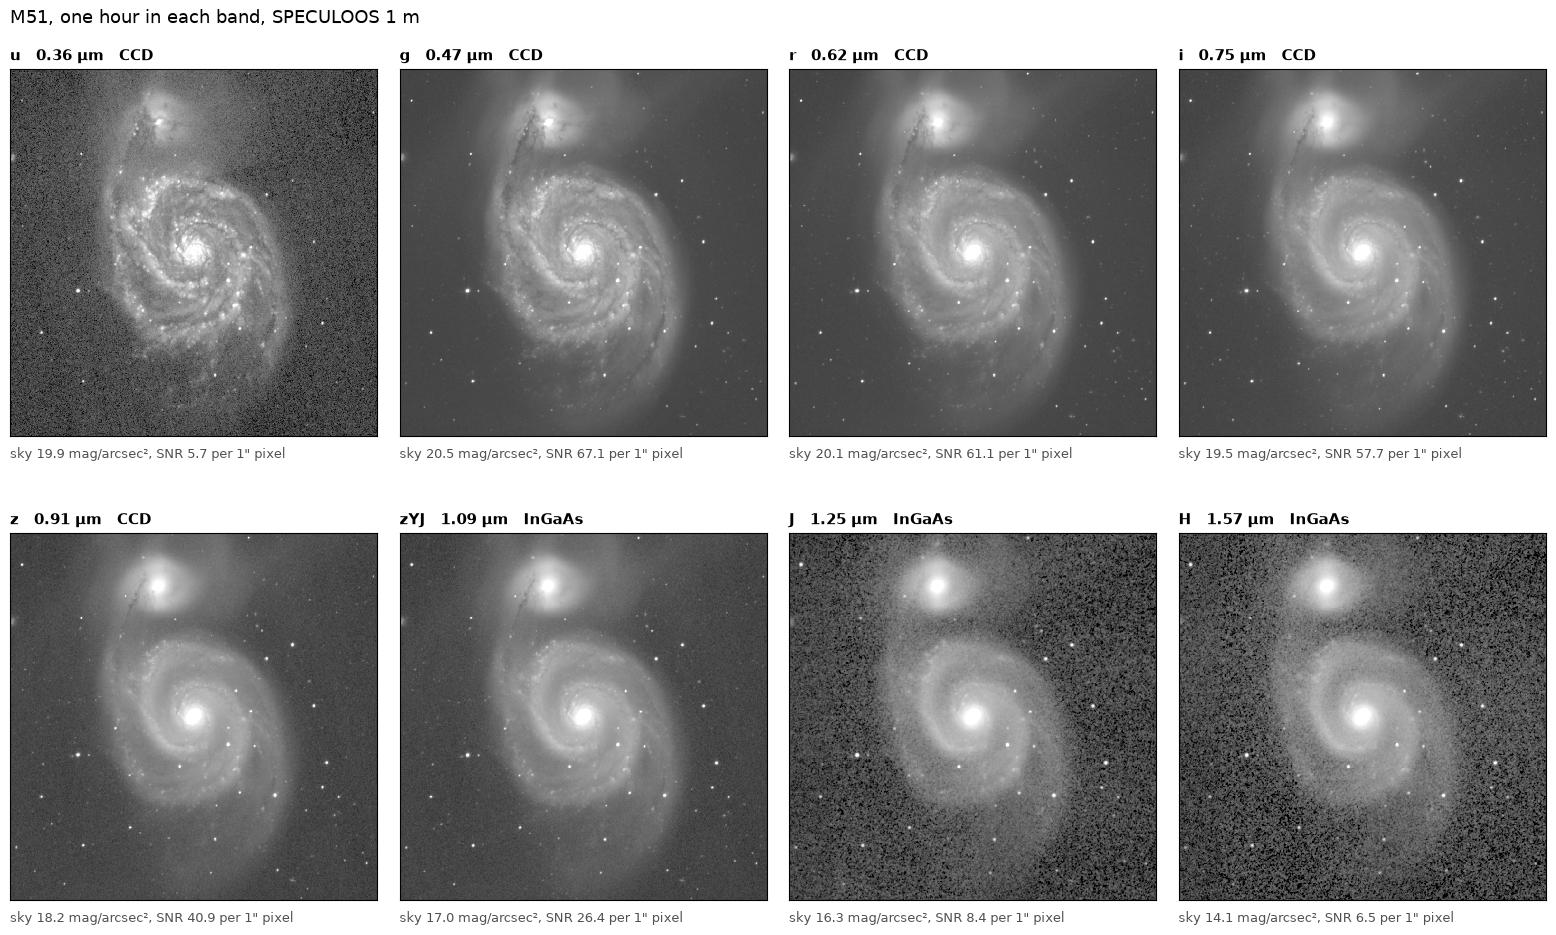

In [8]:
# The images are large. JPEG keeps this notebook small.
%config InlineBackend.figure_formats = ["jpeg"]

from synthetic_images import show, simulate

ccd = {k: v for k, v in props_instrument.items() if k != "name"}
ingaas = {**ccd, "plate_scale": 0.31, "N_dc": 110, "N_rn": 90, "well_depth": 56000, "read_time": 0.1}
systems = {
    "CCD": ("speculoos_Andor_iKon-L-936_-60", ccd),
    "InGaAs": ("speculoos_PIRT_1280SciCam_-60", ingaas),
}
bands = [
    # band, filter, detector, survey for the shape, seeing of the survey ["]
    ("u", "u", "CCD", "CDS/P/SDSS9/u", 1.5),
    ("g", "g", "CCD", "CDS/P/SDSS9/g", 1.4),
    ("r", "r", "CCD", "CDS/P/SDSS9/r", 1.3),
    ("i", "i", "CCD", "CDS/P/SDSS9/i", 1.3),
    ("z", "z", "CCD", "CDS/P/SDSS9/z", 1.3),
    ("zYJ", "zYJ", "InGaAs", "CDS/P/SDSS9/z", 1.3),
    ("J", "J", "InGaAs", "CDS/P/2MASS/J", 2.8),
    ("H", "SPC_H", "InGaAs", "CDS/P/2MASS/H", 2.8),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 9.6))
fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.05, hspace=0.25, wspace=0.06)
for ax, (band, filt, detector, hips, survey_seeing) in zip(axes.flat, bands):
    efficiency, preset = systems[detector]
    band_name, response = mphot.generate_system_response(
        f"../resources/systems/{efficiency}.csv", f"../resources/filters/{filt}.csv"
    )
    props = {**preset, "name": band_name}
    p = mphot.get_exposure_extended(target, props, props_sky)
    n = max(1, round(3600 / p["t_sub [s]"]))
    image, mean = simulate(target, p, props, hips, survey_seeing, 1.35, n_subs=n)

    # SNR in a 1" pixel (3 x 3 detector pixels) at the mean, after one hour.
    s, b, d, rn, t = (p["N_target [e/pix/s]"], p["N_sky [e/pix/s]"], p["N_dc [e/pix/s]"],
                      p["N_rn [e_rms/pix]"], p["t_sub [s]"])
    snr = math.sqrt(9 * n) * s * t / math.sqrt((s + b + d) * t + rn**2)

    lam = response.index.to_numpy()
    centre = np.trapezoid(lam * response, lam) / np.trapezoid(response, lam)
    show(ax, image, mean, f"{band}   {centre:.2f} µm   {detector}",
         f"sky {p['mu_sky [mag/arcsec2]']:.1f} mag/arcsec², SNR {snr:.1f} per 1\" pixel")

fig.suptitle("M51, one hour in each band, SPECULOOS 1 m", x=0.02, ha="left", fontsize=13)
plt.show()

To the red, the sky becomes brighter faster than M51. Thus the SNR decreases.

## Limits

- The shape comes from a survey. The image cannot be sharper than the survey (2MASS: approximately 2.8″).
- *mphot* does not calculate the line emission of galaxies. In an Halpha filter, a galaxy is too faint.
- The brightest part of a galaxy is the centre of an exponential disk. A bulge or nucleus is brighter.